In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False) 

## 1) EDA

In [16]:
df = pd.read_csv('../data/reviews.csv')
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


* Unnamed: 0 : Unnecessary, repetition of the index number. (Must be deleted)
* Clothing ID : Product ID number. (Which product receives the most complaints?)
* Age : Customer's age
* Title : Title of the review. (Valuable additional information for NLP)
* Review Text : The main review text. (The heart of our project)
* Rating : Rating between 1 (worst) and 5 (best)
* Recommended IND : Does the customer recommend it? (1: Yes, 0: No)
* Positive Feedback Count : How many other customers found this review helpful? (Higher means more reliable)
* Division Name : Top category. (General, Petite, Intimates)
* Department Name : Department. (Dresses, Tops, Bottoms etc.)
* Class Name : Specific class. (Blouses, Pants, Knits etc.)

In [39]:
def basic_eda(df):
    print("\n--- Data Summary Info ---")
    print(df.info())

    print("\n--- Shape---")
    print(df.shape)

    print("\n--- Number of Unique Values ---")
    print(df.nunique())
    
    print("\n--- Rating Distribution ---")
    print(df['Rating'].value_counts(normalize=True))
    
    print("\n--- Check Duplicated Rows ---")
    print(df.duplicated().sum())

    print("\n--- Check Null Values ---")
    print(df.isnull().sum())
    
    print("\n--- Distribution of Data ---")
    print(df.describe().T)

basic_eda(df)


--- Data Summary Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB
None

--- Shape---
(23486, 11)

--- Number of Unique Values ---
Unnamed: 0                 23486
Clothing ID                 

### Steps to be Taken
1) I will drop unnamed column because it is same as index numbers.
2) Review Length feature will be added.
3) Some review texts and titles same.
4) 845 null for review text, 3810 null for title.
5) 0 Duplicated rows

#### What Should I Understand From This Data?
- **Imbalanced Data:** 77% of the data consists of 4 and 5-star ratings. People are generally happy. But what's interesting for us is that 3.5% (1 star) and 6% (2 stars) segment.
There is a 'positivity bias' in the dataset. Therefore, it's easy to just predict ratings, but finding anomalies is more valuable.
- **Review Text Losses:** There are no comments in 845 lines. These lines are "garbage" for NLP. I must clean them up immediately. 
- **Category Hierarchy:** Department and Class names give me the chance to do this: "Which department (e.g., Dresses) has more anomalies?"

## 2) Preprocessing 

In [40]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [41]:
df.dropna(subset=['Review Text'], inplace=True)

In [42]:
df["Title"] = df["Title"].fillna(" ")

In [43]:
# New Feature Combine Title and Review Text
df['full_text'] = df['Title'] + ' ' + df['Review Text']

In [44]:
# Fill in the missing category information.
category_cols = ['Division Name', 'Department Name', 'Class Name']
df[category_cols] = df[category_cols].fillna('Unknown')

## 3) Feature Engineering

In [45]:
# New Feature Review Length
df['Review_Length'] = df['Review Text'].apply(lambda x: len(str(x)))    

In [46]:
print("Mean Review Text")
print(df['Review_Length'].mean())

Mean Review Text
308.6879113113378


In [47]:
# New Feature Word Count
df['word_count'] = df['full_text'].str.split().str.len()

In [48]:
# New Feature Number of Exclamation Marks
df['exclamation_count'] = df['full_text'].str.count('!')

In [53]:
df[df["Rating"] == 1].head(5)

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,full_text,Review_Length,word_count,exclamation_count
61,368,36,Itchy tags,"3 tags sewn in, 2 small (about 1'' long) and 1...",1,0,0,Initmates,Intimate,Intimates,"Itchy tags 3 tags sewn in, 2 small (about 1'' ...",484,105,3
85,866,58,,"I was really hoping to like this, but it did n...",1,0,2,General Petite,Tops,Knits,"I was really hoping to like this, but it did...",499,102,0
96,845,44,,I usually wear a medium and bought a small. it...,1,0,0,General Petite,Tops,Blouses,I usually wear a medium and bought a small. ...,238,49,0
97,861,44,Huge,I was very excited to order this top in red xs...,1,0,0,General Petite,Tops,Knits,Huge I was very excited to order this top in r...,157,33,1
110,861,44,Poor quality,This is so thin and poor quality. especially f...,1,0,11,General Petite,Tops,Knits,Poor quality This is so thin and poor quality....,180,34,0


In [54]:
# Grouping ratings by exclamation number count
df.groupby('Rating')['exclamation_count'].mean()

Rating
1    0.617540
2    0.415107
3    0.345731
4    0.530970
5    1.176555
Name: exclamation_count, dtype: float64

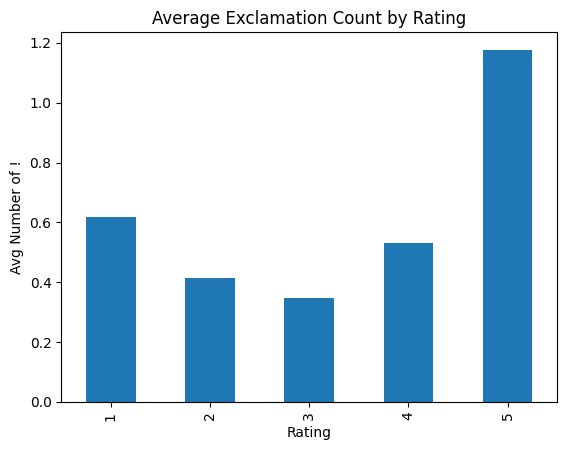

In [55]:
df.groupby('Rating')['exclamation_count'].mean().plot(kind='bar')

plt.title('Average Exclamation Count by Rating')
plt.xlabel('Rating')
plt.ylabel('Avg Number of !')
plt.show()

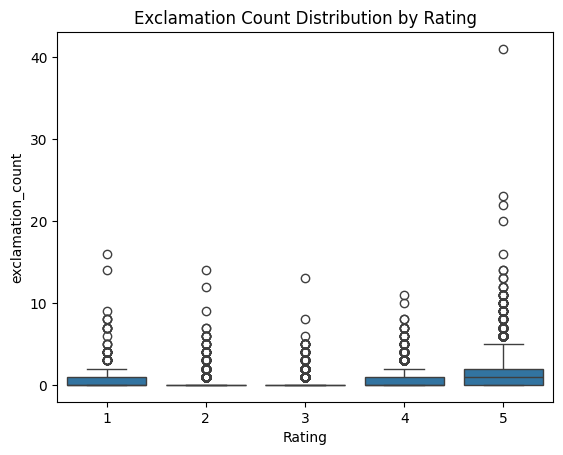

In [56]:
sns.boxplot(x='Rating', y='exclamation_count', data=df)

plt.title('Exclamation Count Distribution by Rating')
plt.show()

In [59]:
df['is_high_exclamation'] = df['exclamation_count'] > 2

In [60]:
df.groupby('Rating')['is_high_exclamation'].mean()

Rating
1    0.057247
2    0.041963
3    0.028693
4    0.047066
5    0.143700
Name: is_high_exclamation, dtype: float64

In [61]:
basic_eda(df)


--- Data Summary Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 22641 entries, 0 to 23485
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              22641 non-null  int64 
 1   Age                      22641 non-null  int64 
 2   Title                    22641 non-null  object
 3   Review Text              22641 non-null  object
 4   Rating                   22641 non-null  int64 
 5   Recommended IND          22641 non-null  int64 
 6   Positive Feedback Count  22641 non-null  int64 
 7   Division Name            22641 non-null  object
 8   Department Name          22641 non-null  object
 9   Class Name               22641 non-null  object
 10  full_text                22641 non-null  object
 11  Review_Length            22641 non-null  int64 
 12  word_count               22641 non-null  int64 
 13  exclamation_count        22641 non-null  int64 
 14  rating_group    

In [62]:
df.to_csv('data/clean_reviews.csv', index=False)